In [1]:
# 挂载Drive + 安装依赖
from google.colab import drive
drive.mount('/content/drive')

!pip install -q torch torchvision
!pip install -q opencv-python-headless matplotlib

import os, sys, json
import numpy as np
sys.path.insert(0, '/content/drive/MyDrive/vegetation_models_v2/6_MobileSAMV2/code')
print('✅ 环境准备完成')

Mounted at /content/drive
✅ 环境准备完成


In [5]:
# 安装MobileSAMV2
# 先安装MobileSAM（提供mobile_sam模块）
!pip install -q git+https://github.com/ChaoningZhang/MobileSAM.git

# 再安装MobileSAMV2
!pip install -q -e /content/drive/MyDrive/vegetation_models_v2/6_MobileSAMV2/code

import sys
sys.path.insert(0, '/content/drive/MyDrive/vegetation_models_v2/6_MobileSAMV2/code')

# 验证
from mobile_sam import sam_model_registry
print('✅ mobile_sam导入成功')
print(f'   可用模型: {list(sam_model_registry.keys())}')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
✅ mobile_sam导入成功
   可用模型: ['default', 'vit_h', 'vit_l', 'vit_b', 'vit_t']


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m

In [6]:
# 数据集（1024x1024，与MobileSAM一致）
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

IMG_SIZE = 1024  # MobileSAMV2 TinyViT同样要求1024x1024

class VegetationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.augment   = augment
        self.images    = []

        for fname in sorted(os.listdir(image_dir)):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            stem      = os.path.splitext(fname)[0]
            img_path  = os.path.join(image_dir, fname)
            mask_path = os.path.join(mask_dir, stem + '.png')
            if not os.path.exists(mask_path):
                mask_path = os.path.join(mask_dir, stem + '.jpg')
            if os.path.exists(img_path) and os.path.exists(mask_path):
                self.images.append((img_path, mask_path))

        print(f'  成功配对: {len(self.images)} 张')

        self.img_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std= [0.229,0.224,0.225])
        ])
        self.aug_transform = transforms.Compose([
            transforms.Resize((int(IMG_SIZE*1.05), int(IMG_SIZE*1.05))),
            transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std= [0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, mask_path = self.images[idx]
        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        if self.augment:
            seed = torch.randint(0, 99999, (1,)).item()
            torch.manual_seed(seed)
            img_tensor = self.aug_transform(img)
            torch.manual_seed(seed)
            mask_np = np.array(
                transforms.Compose([
                    transforms.Resize((int(IMG_SIZE*1.05), int(IMG_SIZE*1.05)),
                                      interpolation=Image.NEAREST),
                    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomVerticalFlip(p=0.5),
                ])(mask)
            )
        else:
            img_tensor = self.img_transform(img)
            mask_np    = np.array(mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST))

        mask_tensor = torch.from_numpy(mask_np).long()
        mask_tensor = (mask_tensor > 0).long()
        return img_tensor, mask_tensor, os.path.basename(img_path)


DATA_2022 = '/content/drive/MyDrive/datasets/2022-seg'
DATA_2023 = '/content/drive/MyDrive/datasets/2023-seg'
DATA_2024 = '/content/drive/MyDrive/datasets/2024-seg'

print('--- 2022训练集 ---')
ds2022 = VegetationDataset(os.path.join(DATA_2022, 'JPEGImages'),
                            os.path.join(DATA_2022, 'SegmentationClass'), augment=True)
print('--- 2023训练集 ---')
ds2023 = VegetationDataset(os.path.join(DATA_2023, 'JPEGImages'),
                            os.path.join(DATA_2023, 'SegmentationClass'), augment=True)
print('--- 2024测试集 ---')
ds2024 = VegetationDataset(os.path.join(DATA_2024, 'JPEGImages'),
                            os.path.join(DATA_2024, 'SegmentationClass'), augment=False)

train_dataset = ConcatDataset([ds2022, ds2023])
test_dataset  = ds2024

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'\n✅ 训练集: {len(train_dataset)} 张 | 测试集: {len(test_dataset)} 张')

--- 2022训练集 ---
  成功配对: 67 张
--- 2023训练集 ---
  成功配对: 67 张
--- 2024测试集 ---
  成功配对: 67 张

✅ 训练集: 134 张 | 测试集: 67 张


In [7]:
# 构建MobileSAMV2分割模型
import torch
import torch.nn as nn

class MobileSAMV2Seg(nn.Module):
    def __init__(self, ckpt_path, num_classes=2):
        super().__init__()
        # MobileSAMV2的image encoder与MobileSAM相同（TinyViT）
        # 但额外包含ObjectAwareModel用于prompt sampling
        # 这里用于语义分割，只需要image encoder部分
        from mobile_sam import sam_model_registry
        sam = sam_model_registry['vit_t'](checkpoint=ckpt_path)
        self.encoder = sam.image_encoder  # TinyViT，输出[B, 256, 64, 64]

        self.seg_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1),
            nn.Upsample(size=(1024, 1024), mode='bilinear', align_corners=False)
        )

    def forward(self, x):
        feat = self.encoder(x)
        return self.seg_head(feat)

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad = True
        print('🔓 全部参数解冻，全量微调')


DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
# MobileSAMV2用mobile_sam.pt作为image encoder权重
CKPT_PATH = '/content/drive/MyDrive/vegetation_models_v2/6_MobileSAMV2/weights/mobile_sam.pt'

print(f'🔧 设备: {DEVICE}')
print('📦 加载MobileSAMV2...')
model = MobileSAMV2Seg(CKPT_PATH, num_classes=2).to(DEVICE)
model.unfreeze_all()

total   = sum(p.numel() for p in model.parameters())
encoder = sum(p.numel() for p in model.encoder.parameters())
head    = sum(p.numel() for p in model.seg_head.parameters())
print(f'✅ MobileSAMV2加载完成')
print(f'   总参数: {total:,} | Encoder: {encoder:,} | Head: {head:,}')

🔧 设备: cuda
📦 加载MobileSAMV2...
🔓 全部参数解冻，全量微调
✅ MobileSAMV2加载完成
   总参数: 7,025,470 | Encoder: 6,065,532 | Head: 959,938


In [8]:
# 损失函数 + 评估
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1.0):
    pred   = torch.softmax(pred, dim=1)[:, 1]
    target = target.float()
    inter  = (pred * target).sum(dim=(1,2))
    union  = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return 1 - ((2*inter + smooth) / (union + smooth)).mean()

def focal_loss(pred, target, gamma=2.0, alpha=0.75):
    ce = F.cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-ce)
    w  = target.float() * alpha + (1 - target.float()) * (1 - alpha)
    return (w * (1 - pt)**gamma * ce).mean()

def combined_loss(pred, target):
    return 0.4 * focal_loss(pred, target) + 0.6 * dice_loss(pred, target)

def evaluate(model, loader, device):
    model.eval()
    iou_list, acc_list, f1_list = [], [], []
    with torch.no_grad():
        for imgs, masks, _ in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = torch.argmax(model(imgs), dim=1)
            tp = ((preds==1) & (masks==1)).sum().item()
            fp = ((preds==1) & (masks==0)).sum().item()
            fn = ((preds==0) & (masks==1)).sum().item()
            tn = ((preds==0) & (masks==0)).sum().item()
            iou_list.append(tp / (tp+fp+fn+1e-6))
            acc_list.append((tp+tn) / (tp+fp+fn+tn+1e-6))
            f1_list.append(2*tp / (2*tp+fp+fn+1e-6))
    return np.mean(iou_list), np.mean(acc_list), np.mean(f1_list)

print('✅ 损失函数定义完成')

✅ 损失函数定义完成


In [9]:
# 全量微调训练
import torch.optim as optim
from torch.amp import autocast, GradScaler

SAVE_DIR   = '/content/drive/MyDrive/vegetation_models_v2/6_MobileSAMV2/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_EPOCHS = 100
best_iou   = 0
train_log  = []
scaler     = GradScaler('cuda')

optimizer = optim.AdamW([
    {'params': model.encoder.parameters(),  'lr': 5e-5},
    {'params': model.seg_head.parameters(), 'lr': 5e-4},
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('='*60)
print(f'🚀 MobileSAMV2 全量微调，{NUM_EPOCHS}轮，batch=8，设备: {DEVICE}')
print(f'   可训练参数: {trainable:,}')
print('='*60)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        with autocast('cuda'):
            loss = combined_loss(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    iou, acc, f1 = evaluate(model, test_loader, DEVICE)
    train_log.append({'epoch': epoch, 'loss': avg_loss,
                      'iou': iou, 'acc': acc, 'f1': f1})

    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
          f'Loss: {avg_loss:.4f} | IoU: {iou:.4f} | '
          f'F1: {f1:.4f} | Acc: {acc:.4f}')

    if iou > best_iou:
        best_iou = iou
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'best_iou': best_iou
        }, os.path.join(SAVE_DIR, 'mobilesamv2_best.pth'))
        print(f'  💾 最优模型保存 (IoU={best_iou:.4f})')

with open(os.path.join(SAVE_DIR, 'train_log.json'), 'w') as f:
    json.dump(train_log, f, indent=2)

print('='*60)
print(f'✅ 训练完成！最优IoU: {best_iou:.4f}')

🚀 MobileSAMV2 全量微调，100轮，batch=8，设备: cuda
   可训练参数: 7,025,470
Epoch [001/100] Loss: 0.2224 | IoU: 0.6103 | F1: 0.7145 | Acc: 0.6111
  💾 最优模型保存 (IoU=0.6103)
Epoch [002/100] Loss: 0.1716 | IoU: 0.6773 | F1: 0.7789 | Acc: 0.7761
  💾 最优模型保存 (IoU=0.6773)
Epoch [003/100] Loss: 0.1654 | IoU: 0.7158 | F1: 0.8168 | Acc: 0.8507
  💾 最优模型保存 (IoU=0.7158)
Epoch [004/100] Loss: 0.1493 | IoU: 0.7243 | F1: 0.8226 | Acc: 0.8602
  💾 最优模型保存 (IoU=0.7243)
Epoch [005/100] Loss: 0.1379 | IoU: 0.7172 | F1: 0.8172 | Acc: 0.8573
Epoch [006/100] Loss: 0.1389 | IoU: 0.7229 | F1: 0.8213 | Acc: 0.8623
Epoch [007/100] Loss: 0.1255 | IoU: 0.6773 | F1: 0.7904 | Acc: 0.8307
Epoch [008/100] Loss: 0.1337 | IoU: 0.6701 | F1: 0.7796 | Acc: 0.8384
Epoch [009/100] Loss: 0.1238 | IoU: 0.7085 | F1: 0.8118 | Acc: 0.8527
Epoch [010/100] Loss: 0.1289 | IoU: 0.7178 | F1: 0.8163 | Acc: 0.8633
Epoch [011/100] Loss: 0.1269 | IoU: 0.7189 | F1: 0.8159 | Acc: 0.8653
Epoch [012/100] Loss: 0.1165 | IoU: 0.6604 | F1: 0.7784 | Acc: 0.8205
Epo

In [10]:
# 测试集评估 + 可视化
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ckpt = torch.load(os.path.join(SAVE_DIR, 'mobilesamv2_best.pth'),
                  map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'✅ 加载最优模型 (epoch={ckpt["epoch"]}, IoU={ckpt["best_iou"]:.4f})')

test_iou, test_acc, test_f1 = evaluate(model, test_loader, DEVICE)
print(f'\n📊 2024测试集最终结果:')
print(f'   mIoU:           {test_iou:.4f}')
print(f'   F1 Score:       {test_f1:.4f}')
print(f'   Pixel Accuracy: {test_acc:.4f}')

model.eval()
fig, axes = plt.subplots(6, 3, figsize=(12, 24))
axes[0][0].set_title('原图',          fontsize=13)
axes[0][1].set_title('真实标注',      fontsize=13)
axes[0][2].set_title('MobileSAMV2预测', fontsize=13)

count = 0
with torch.no_grad():
    for imgs, masks, names in test_loader:
        preds = torch.argmax(model(imgs.to(DEVICE)), dim=1).cpu()
        for i in range(imgs.size(0)):
            if count >= 6: break
            img_np = imgs[i].permute(1,2,0).numpy()
            img_np = np.clip(img_np * np.array([0.229,0.224,0.225])
                             + np.array([0.485,0.456,0.406]), 0, 1)
            axes[count][0].imshow(img_np)
            axes[count][0].set_ylabel(names[i], fontsize=7,
                                       rotation=0, labelpad=60)
            axes[count][1].imshow(masks[i].numpy(), cmap='Greens', vmin=0, vmax=1)
            axes[count][2].imshow(preds[i].numpy(), cmap='Greens', vmin=0, vmax=1)
            for ax in axes[count]: ax.axis('off')
            count += 1
        if count >= 6: break

fig.legend(handles=[
    mpatches.Patch(color='green', label='植被'),
    mpatches.Patch(color='black', label='背景')
], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.01))
plt.suptitle(f'MobileSAMV2 2024测试集结果\n'
             f'IoU={test_iou:.4f} | F1={test_f1:.4f} | Acc={test_acc:.4f}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mobilesamv2_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 可视化已保存')

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1040/2535348101.py:22: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}

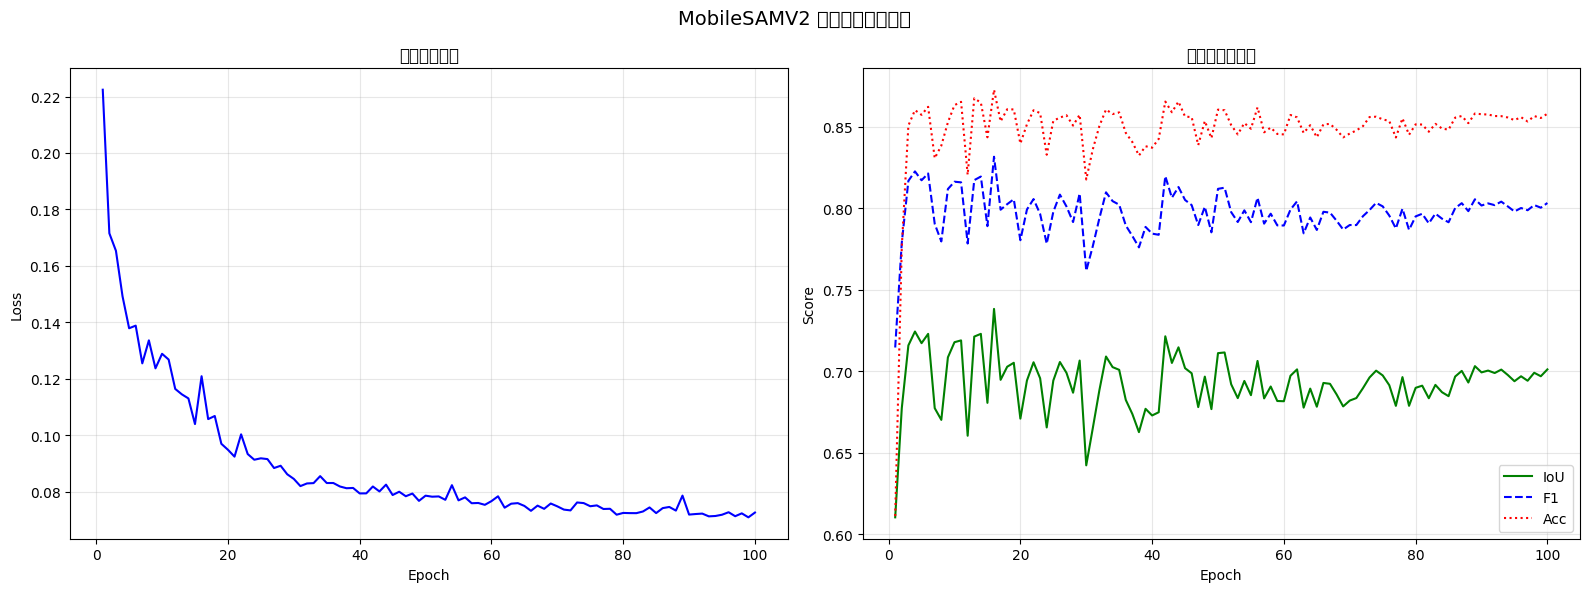

✅ 训练曲线已保存


In [11]:
# 训练曲线
log    = train_log
epochs = [x['epoch'] for x in log]
losses = [x['loss']  for x in log]
ious   = [x['iou']   for x in log]
f1s    = [x['f1']    for x in log]
accs   = [x['acc']   for x in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs, losses, 'b-', linewidth=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('训练损失曲线'); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, ious, 'g-',  linewidth=1.5, label='IoU')
ax2.plot(epochs, f1s,  'b--', linewidth=1.5, label='F1')
ax2.plot(epochs, accs, 'r:',  linewidth=1.5, label='Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('验证集指标曲线'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('MobileSAMV2 全量微调训练过程', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'mobilesamv2_train_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 训练曲线已保存')